# Applied Statistics Project
*****

## Introduction

## Imports

In [39]:
# Standard mathematical functions
# https://docs.python.org/3/library/math.html
import math

# Numerical structures and operations
# https://numpy.org/doc/stable/user/index.html#user
import numpy as np

# Permutations and combinations
# https://docs.python.org/3/library/itertools.html
import itertools

# Generate pseudo-random numbers
# https://docs.python.org/3/library/random.html
# import random

# Create plots
# https://matplotlib.org/stable/users/index.html
import matplotlib.pyplot as plt

# Statistical functions
# https://docs.scipy.org/doc/scipy/reference/stats.html
import scipy.stats as stats

In [40]:
# create random number generator for problems 2 3 and 4
# https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.normal.html#numpy.random.Generator.normal
generator=np.random.default_rng()

## Problem 1: Extending the Lady Tasting Tea 

The goal here is to extend the original lady tasting tea experiment (<i>Fisher, 1935</i>), where a participant is presented with a set of randomly-shuffled cups of tea and claims to be able to tell which cups had the milk poured in before the tea. The original experiment used 8 cups of tea (4 with the tea poured first and 4 with the milk poured first). We are going to use 12 cups (8 tea-first and 4 milk-first), and calculate the probability of the participant correctly identifying the preparation method for each cup.

### Prepare the cups

In [41]:
# number of cups
n_cups = 12

# number of cups with milk added first
cups_milk_first = 4

# number of cups with tea added first
cups_tea_first = 8

### Calculating possible combinations

In mathematics, the choose function allows us to calculate the number of possible combinations when selecting <i>n</i> objects from a set of <i>k</i> objects  without order and without repetition i.e. each object can only be selected once.

![combination formula](https://wikimedia.org/api/rest_v1/media/math/render/svg/0f4e3f6d2dc3075f5569c82118fad11c32dff393)

#### Calculating possible combinations using math.factorial

The [math.factorial](https://docs.python.org/3/library/math.html#math.factorial) function allows us to easily make the calculations necessary for the choose function.

In [42]:
# total number of cups
n = 12

# number of cups with milk first
k = 4

In [43]:
math.factorial(n)

479001600

In [44]:
math.factorial(k)

24

In [45]:
math.factorial(n-k)

40320

In [46]:
# using the choose function
math.factorial(n)//(math.factorial(k)*math.factorial(n-k))

495

#### Calculating possible combinations using math.comb

The [math.comb](https://docs.python.org/3/library/math.html#math.comb) function condenses the above steps into one.

In [47]:
# number of possible combinations when selecting 8 cups from the 12 presented
combinations = math.comb(n_cups, cups_milk_first)
combinations

495

### Ordering the Results

In [48]:
#label the cups
labels = list(range(n_cups))
labels

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

In [49]:
# show how many unique ways there are of selecting cups_milk_first from n_cups
combs = list(itertools.combinations(labels, cups_milk_first))
len(combs)

495

In [50]:
# shuffle the prepared cups
# https://numpy.org/doc/stable/reference/random/generated/numpy.random.shuffle.html
np.random.shuffle(labels)
labels

[4, 1, 6, 2, 9, 5, 10, 11, 0, 7, 8, 3]

In [51]:
# select 4 cups
# https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html
choice = np.random.choice(labels, size = 4, replace = False)
choice

array([9, 3, 1, 2])

In [52]:
# calculate the overlap between each element of combs and choice
overlaps_amount = []
for comb in combs:
    # Turn comb into a set
    set1 = set(comb)
    # Turn choice into a set
    set2 = set(choice)
    # See if they overlap
    overlap = set1.intersection(set2)
    # Append the overlap to overlaps_amount
    overlaps_amount.append(len(overlap))

In [53]:
count = np.unique(overlaps_amount, return_counts = True)
count

(array([0, 1, 2, 3, 4]), array([ 70, 224, 168,  32,   1]))

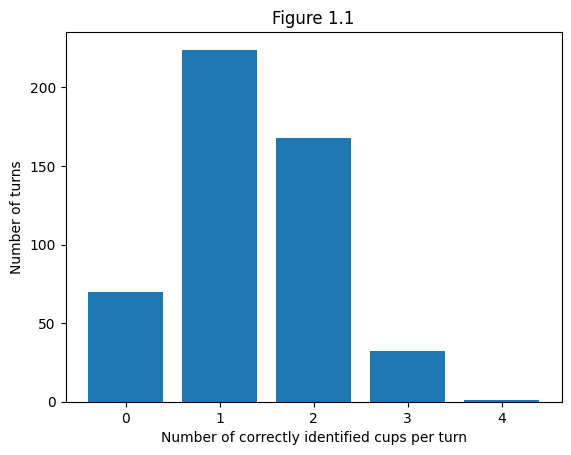

In [54]:
fig, ax = plt.subplots()
ax.bar(count[0], count[1])
ax.set_title("Figure 1.1")
ax.set_xlabel("Number of correctly identified cups per turn")
ax.set_ylabel("Number of turns");

### Null Hypothesis

1. The participant has no special ability to discern the preparation method for each cup
2. The participant is selecting 4 cups at random and declaring them to have been prepared with the milk added before the tea infusion.

### Alternate Hypothesis

1. The participant is able to identify the cups which were prepared with the milk added before the tea infusion.

The probability that the participant will correctly identify the 4 cups with milk added first is 1/495, if they are selecting cups at random. If they do select the correct 4 cups, it is so unlikley that they would have done this by random chance that there is likely something non-random happening when they are making their selection.

In [55]:
# probability of participant randomly selecting 4 correct cups
1/495

0.00202020202020202

In [56]:
# probability of randomly selecting at least 3 correct cups
(32+1)/495

0.06666666666666667

## Problem 2: Normal Distribution

<s>generate 100,000 samples of size 10 from standard normal distribution</s>

<s>compute standard deviation with ddof=1 and ddof=0 for each sample</s>

<s>plot histograms of both sets of values on the same axes with transparency</s>

describe differences

explain how differences are expected to change with larger sample sizes

This problem begins with generating 100,000 samples of size 10 from the standard normal distribution. We then compute the standard deviation with two different [degrees of freedom](https://en.wikipedia.org/wiki/Degrees_of_freedom_(statistics)), 0 and 1.

In [57]:
ddof0=[]
ddof1=[]
# https://wiki.python.org/moin/ForLoop
for s in range(0,100000): #run loop 100,000 times
    # generate sample of size 10 
    samples=generator.normal(size=10)
    # calculate standard deviation with ddof=0 https://numpy.org/doc/stable/reference/generated/numpy.std.html
    samples_ddof0=np.std(samples,ddof=0)
    # calculate standard deviation with ddof=1
    samples_ddof1=np.std(samples,ddof=1)
    # add standard deviation values to ddof0 and ddof1
    ddof0.append(samples_ddof0)
    ddof1.append(samples_ddof1)

Once we have the values for `ddof=0` and `ddof=1`, we plot histograms of both sets of values on the same axes with transparency.

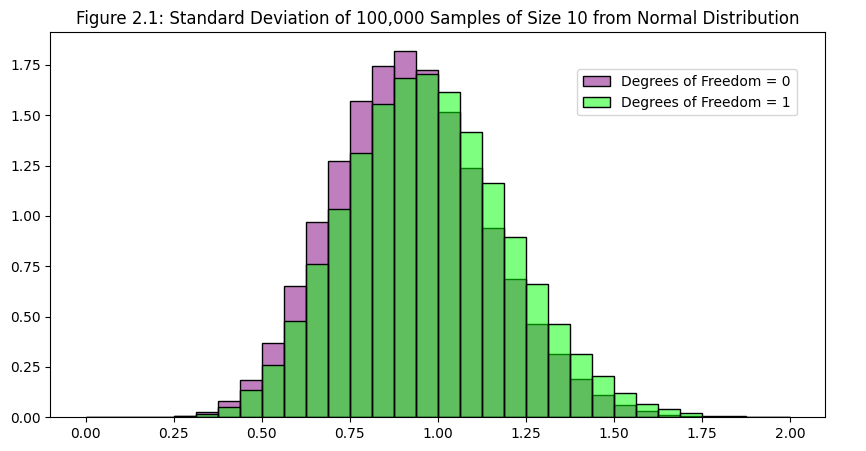

In [58]:
fig,ax=plt.subplots(figsize=(10,5))
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html#matplotlib-pyplot-hist
# transparent bars: https://stackoverflow.com/questions/28398200/plotting-transparent-histogram-with-non-transparent-edge
ax.hist(ddof0, edgecolor='black', density=True, bins=np.linspace(0,2,33), fc=(0.5,0,0.5,0.5), label='Degrees of Freedom = 0')
ax.hist(ddof1, edgecolor='black', density=True, bins=np.linspace(0,2,33), fc=(0,1,0,0.5), label='Degrees of Freedom = 1')
fig.legend(borderaxespad=5) # keep legend inside plot: https://stackoverflow.com/questions/57926148/how-to-keep-legends-inside-plot
ax.set_title('Figure 2.1: Standard Deviation of 100,000 Samples of Size 10 from Normal Distribution');

## Problem 3: t-Tests

<s>2 samples of size 100, one from standard normal distribution and one from normal distribution with mean d and sd 1

run independent samples t-test on both, reject null hypothesis if p-value is less than 0.05

record proportion of times null hypothesis is not rejected

repeat 1000 times for each d

plot proportion against d</s>

explain how type II error rate changes as difference in means increases

find more efficient way to generate samples
check if using d correctly

https://en.wikipedia.org/wiki/Student%27s_t-test

[Type II errors](https://en.wikipedia.org/wiki/Type_I_and_type_II_errors), also known as false negatives, occur when the null hypothesis is not rejected despite being false.

In [59]:
d=[0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]

In [60]:
null_nr1=[]
for s in range (0,1000):
    # samples from standard normal distribution
    ttest_1=generator.normal(size=100)
    # samples with d=0
    samples_1=generator.normal(d[0],1,100)
    # independent t-test 
    # https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html#scipy.stats.ttest_ind
    ttest1, pvalue1=stats.ttest_ind(ttest_1,samples_1)
    if pvalue1>=0.05:
        null_nr1.append(pvalue1)
y1=((len(null_nr1))/1000)*100
print(f"Percentage of times null hypothesis accepted: {y1}%")

Percentage of times null hypothesis accepted: 95.3%


In [61]:
null_nr2=[]
for s in range (0,1000):
    # samples from standard normal distribution
    ttest_2=generator.normal(size=100)
    # samples with d=0.1
    samples_2=generator.normal(d[1],1,100)
    # independent t-test 
    ttest2, pvalue2=stats.ttest_ind(ttest_2,samples_2)
    if pvalue2>=0.05:
        null_nr2.append(pvalue2)
y2=((len(null_nr2))/1000)*100
print(f"Percentage of times null hypothesis accepted: {y2}%")

Percentage of times null hypothesis accepted: 88.3%


In [62]:
null_nr3=[]
for s in range (0,1000):
    # samples from standard normal distribution
    ttest_3=generator.normal(size=100)
    # samples with d=0.2
    samples_3=generator.normal(d[2],1,100)
    # independent t-test 
    ttest3, pvalue3=stats.ttest_ind(ttest_3,samples_3)
    if pvalue3>=0.05:
        null_nr3.append(pvalue3)
y3=((len(null_nr3))/1000)*100
print(f"Percentage of times null hypothesis accepted: {y3}%")

Percentage of times null hypothesis accepted: 69.5%


In [63]:
null_nr4=[]
for s in range (0,1000):
    # samples from standard normal distribution
    ttest_4=generator.normal(size=100)
    # samples with d=0.3
    samples_4=generator.normal(d[3],1,100)
    # independent t-test 
    ttest4, pvalue4=stats.ttest_ind(ttest_4,samples_4)
    if pvalue4>=0.05:
        null_nr4.append(pvalue4)
y4=((len(null_nr4))/1000)*100
print(f"Percentage of times null hypothesis accepted: {y4}%")

Percentage of times null hypothesis accepted: 45.5%


In [64]:
null_nr5=[]
for s in range (0,1000):
    # samples from standard normal distribution
    ttest_5=generator.normal(size=100)
    # samples with d=0.4
    samples_5=generator.normal(d[4],1,100)
    # independent t-test 
    ttest5, pvalue5=stats.ttest_ind(ttest_5,samples_5)
    if pvalue5>=0.05:
        null_nr5.append(pvalue5)
y5=((len(null_nr5))/1000)*100
print(f"Percentage of times null hypothesis accepted: {y5}%")

Percentage of times null hypothesis accepted: 19.5%


In [65]:
null_nr6=[]
for s in range (0,1000):
    # samples from standard normal distribution
    ttest_6=generator.normal(size=100)
    # samples with d=0.5
    samples_6=generator.normal(d[5],1,100)
    # independent t-test 
    ttest6, pvalue6=stats.ttest_ind(ttest_6,samples_6)
    if pvalue6>=0.05:
        null_nr6.append(pvalue6)
y6=((len(null_nr6))/1000)*100
print(f"Percentage of times null hypothesis accepted: {y6}%")

Percentage of times null hypothesis accepted: 4.9%


In [66]:
null_nr7=[]
for s in range (0,1000):
    # samples from standard normal distribution
    ttest_7=generator.normal(size=100)
    # samples with d=0.6
    samples_7=generator.normal(d[6],1,100)
    # independent t-test 
    ttest7, pvalue7=stats.ttest_ind(ttest_7,samples_7)
    if pvalue7>=0.05:
        null_nr7.append(pvalue7)
y7=((len(null_nr7))/1000)*100
print(f"Percentage of times null hypothesis accepted: {y7}%")

Percentage of times null hypothesis accepted: 0.8%


In [67]:
null_nr8=[]
for s in range (0,1000):
    # samples from standard normal distribution
    ttest_8=generator.normal(size=100)
    # samples with d=0.7
    samples_8=generator.normal(d[7],1,100)
    # independent t-test 
    ttest8, pvalue8=stats.ttest_ind(ttest_8,samples_8)
    if pvalue8>=0.05:
        null_nr8.append(pvalue8)
y8=((len(null_nr8))/1000)*100 
print(f"Percentage of times null hypothesis accepted: {y8}%")       

Percentage of times null hypothesis accepted: 0.0%


In [68]:
null_nr9=[]
for s in range (0,1000):
    # samples from standard normal distribution
    ttest_9=generator.normal(size=100)
    # samples with d=0.8
    samples_9=generator.normal(d[8],1,100)
    # independent t-test 
    ttest9, pvalue9=stats.ttest_ind(ttest_9,samples_9)
    if pvalue9>=0.05:
        null_nr9.append(pvalue9)
y9=((len(null_nr9))/1000)*100
print(f"Percentage of times null hypothesis accepted: {y9}%")        

Percentage of times null hypothesis accepted: 0.0%


In [69]:
null_nr10=[]
for s in range (0,1000):
    # samples from standard normal distribution
    ttest_10=generator.normal(size=100)
    # samples with d=0.9
    samples_10=generator.normal(d[9],1,100)
    # independent t-test 
    ttest10, pvalue10=stats.ttest_ind(ttest_10,samples_10)
    if pvalue10>=0.05:
        null_nr10.append(pvalue10)
y10=((len(null_nr10))/1000)*100  
print(f"Percentage of times null hypothesis accepted: {y10}%")      

Percentage of times null hypothesis accepted: 0.0%


In [70]:
null_nr11=[]
for s in range (0,1000):
    # samples from standard normal distribution
    ttest_11=generator.normal(size=100)
    # samples with d=1
    samples_11=generator.normal(d[10],1,100)
    # independent t-test 
    ttest11, pvalue11=stats.ttest_ind(ttest_11,samples_11)
    if pvalue11>=0.05:
        null_nr11.append(pvalue11)
y11=((len(null_nr11))/1000)*100
print(f"Percentage of times null hypothesis accepted: {y11}%")

Percentage of times null hypothesis accepted: 0.0%


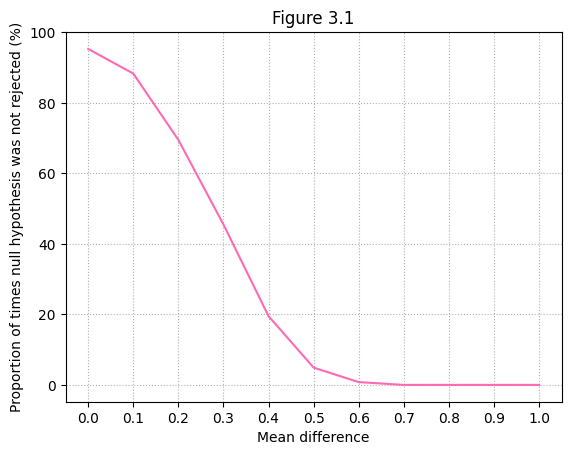

In [71]:
y_values=(y1,y2,y3,y4,y5,y6,y7,y8,y9,y10,y11)
fig,ax=plt.subplots()
ax.plot(d,y_values, color="hotpink")
ax.set_xticks(d)
ax.set_title("Figure 3.1")
ax.set_xlabel("Mean difference")
ax.set_ylabel("Proportion of times null hypothesis was not rejected (%)")
ax.grid(linestyle='dotted');

The type II error rate drops sharply as mean difference increases in 0.1 increments; after mean difference of 0.7 null hypothesis is almost always rejected

## Problem 4: ANOVA

<s>3 independent samples of size 30 from normal distributions with means 0, 0.5 and 1 and sd 1</s>

one way ANOVA to test whether all 3 means are equal

3 independent 2-sample t-tests: samples 1 vs 2, 1 vs 3, 2 vs 3

compare conclusions

short note on why ANOVA is preferred to multiple t-tests

https://researchmethod.net/anova/

In [ ]:
# generate samples
anova_1=generator.normal(0,1,30)
anova_2=generator.normal(0.5,1,30)
anova_3=generator.normal(1,1,30)

In [ ]:
# perform one-way ANOVA test
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.f_oneway.html
stats.f_oneway(anova_1,anova_2,anova_3)

F_onewayResult(statistic=np.float64(33.320258748208495), pvalue=np.float64(1.8033784365960117e-11))

In [ ]:
# perform independent t-tests
tttest4_1, pvalue4_1=stats.ttest_ind(anova_1,anova_2)
ttest4_2, pvalue4_2=stats.ttest_ind(anova_1,anova_3)
ttest4_3, pvalue4_3=stats.ttest_ind(anova_2,anova_3)

In [ ]:
# calculates means of pvalues for comparison with ANOVA?
#np.mean(pvalue4_1,pvalue4_2,pvalue4_3, dtype=np.float64)

TypeError: mean() got multiple values for argument 'dtype'

In [ ]:
(pvalue4_1+pvalue4_2+pvalue4_3)/3
# means are radically different, unsure if this is the expected result

np.float64(0.0004889984676250021)

### References

*****
# End